Using device: cuda
wd 0.0001, lr 0.005, batch_size 1024, layer_size 1024, num_layer 1
epoch 004 | lr 5.00e-03, recon: 21.60223388671875, kl_x : 11.259479522705078 , kl_H : 13.76593017578125
Execution time: 0.05643551349639893 minutes, epoch: 4


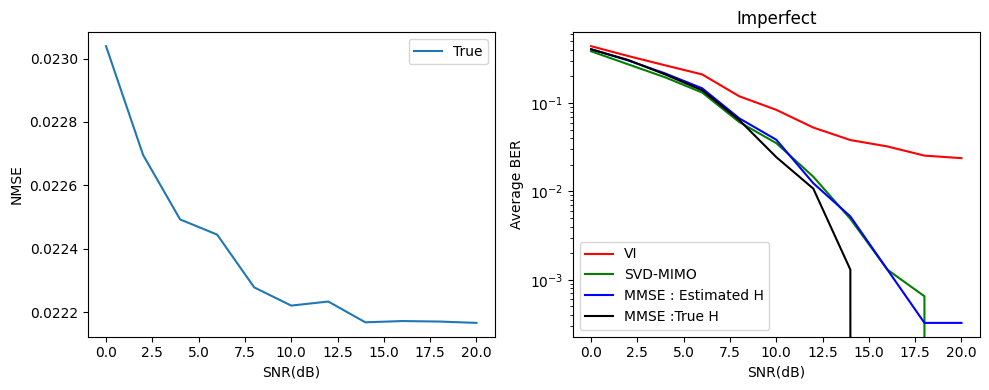

epoch 009 | lr 5.00e-03, recon: 18.95077133178711, kl_x : 10.650979995727539 , kl_H : 4.9842529296875
Execution time: 0.11698996225992839 minutes, epoch: 9


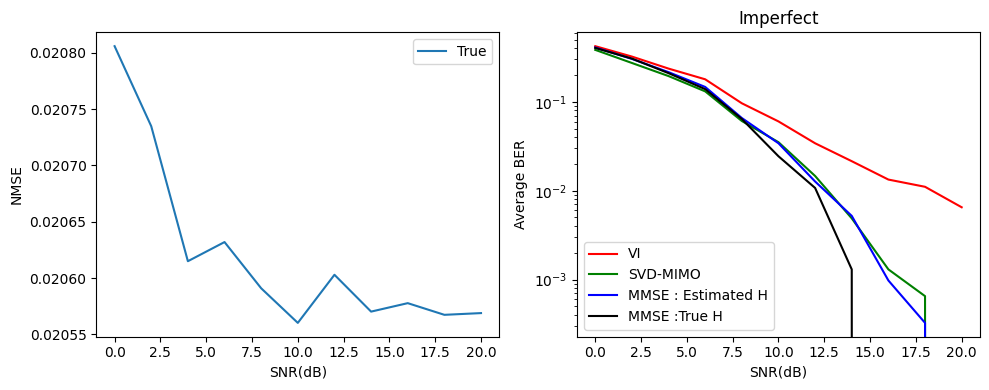

epoch 014 | lr 5.00e-03, recon: 18.119213104248047, kl_x : 10.441171646118164 , kl_H : 2.777313232421875
Execution time: 0.179502272605896 minutes, epoch: 14


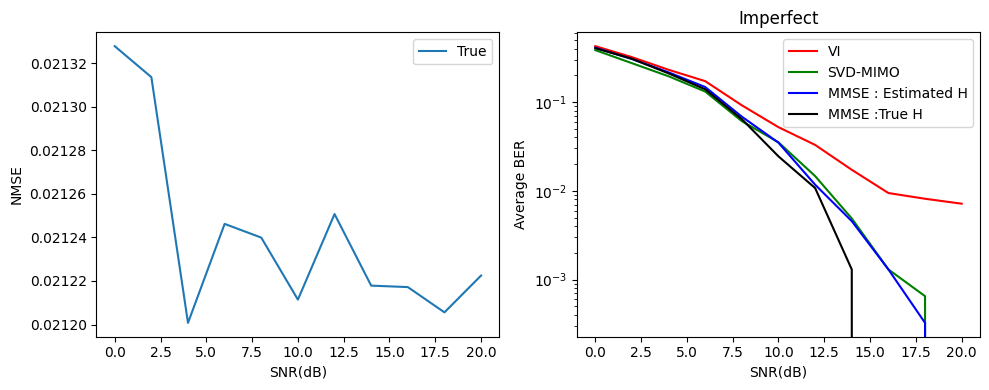

epoch 019 | lr 5.00e-03, recon: 17.65315055847168, kl_x : 10.360803604125977 , kl_H : 2.335540771484375
Execution time: 0.24004041751225788 minutes, epoch: 19


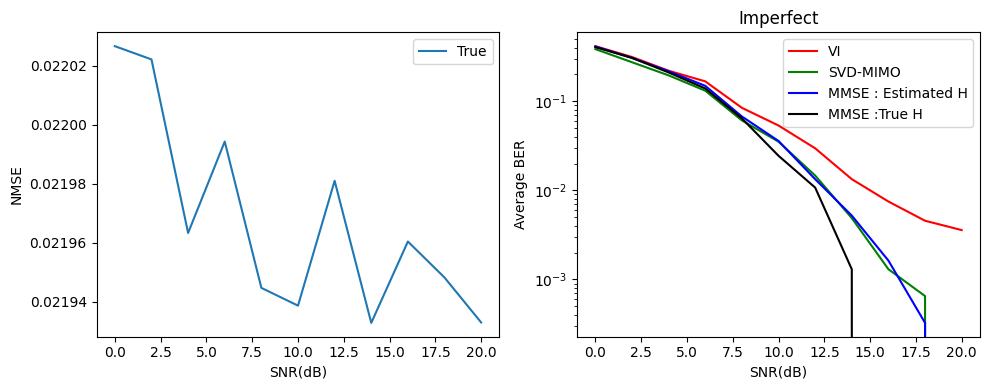

epoch 024 | lr 5.00e-03, recon: 17.511764526367188, kl_x : 10.415428161621094 , kl_H : 2.72406005859375
Execution time: 0.30037153164545694 minutes, epoch: 24


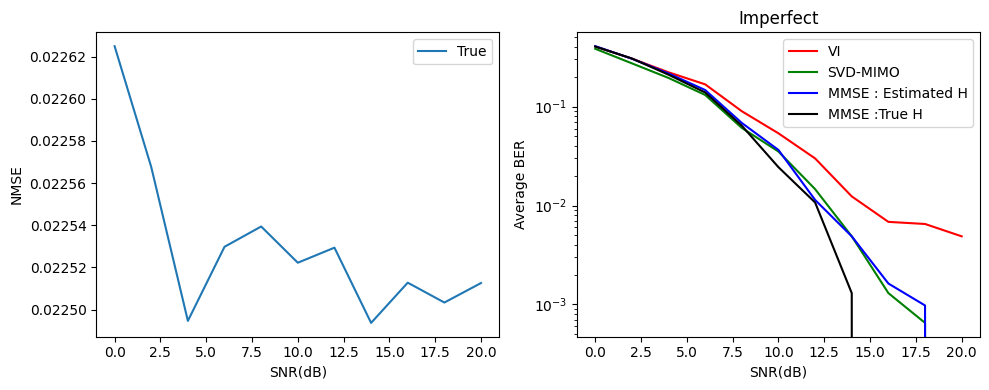

epoch 029 | lr 5.00e-03, recon: 17.802648544311523, kl_x : 10.267339706420898 , kl_H : 1.985931396484375
Execution time: 0.36274393399556476 minutes, epoch: 29


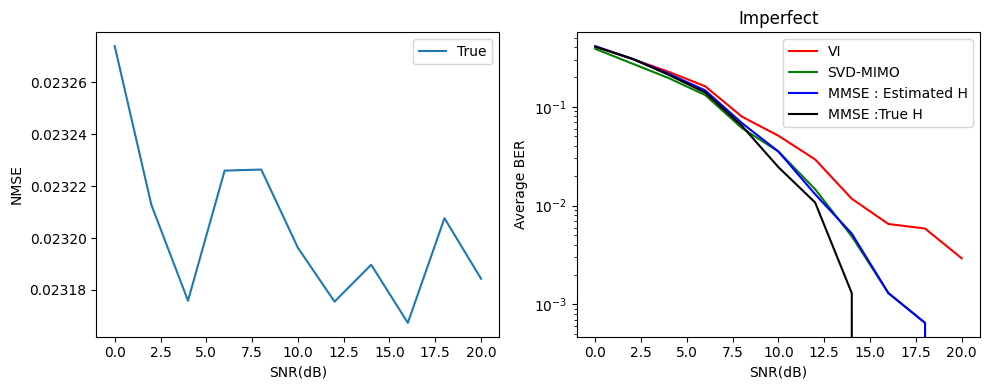

epoch 034 | lr 5.00e-03, recon: 17.652002334594727, kl_x : 10.15641975402832 , kl_H : 1.272125244140625
Execution time: 0.422788135210673 minutes, epoch: 34


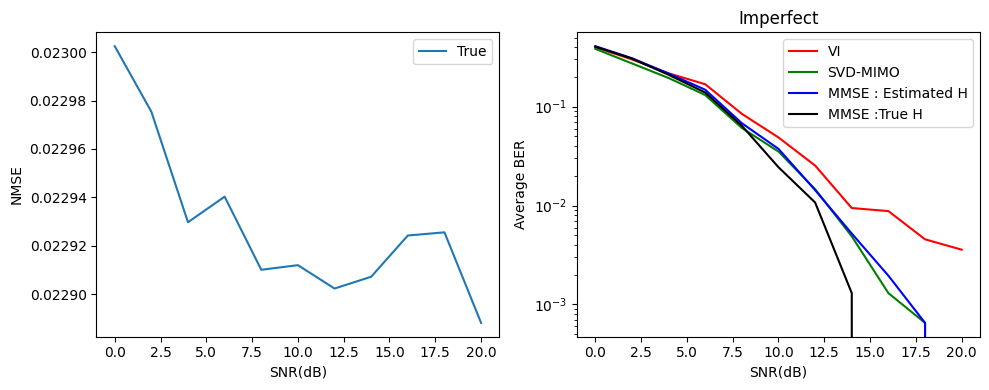

epoch 039 | lr 5.00e-03, recon: 17.671499252319336, kl_x : 10.0606689453125 , kl_H : 1.3721923828125
Execution time: 0.4857996980349223 minutes, epoch: 39


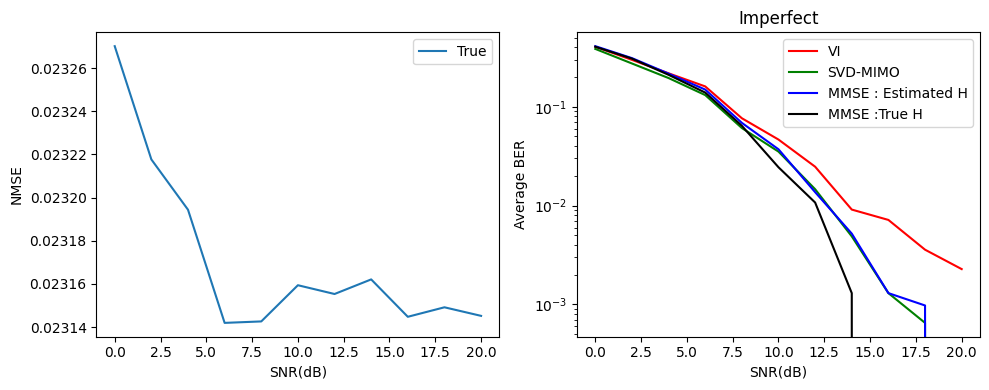

epoch 044 | lr 5.00e-03, recon: 17.07267189025879, kl_x : 10.259819030761719 , kl_H : 2.325836181640625
Execution time: 0.5460530519485474 minutes, epoch: 44


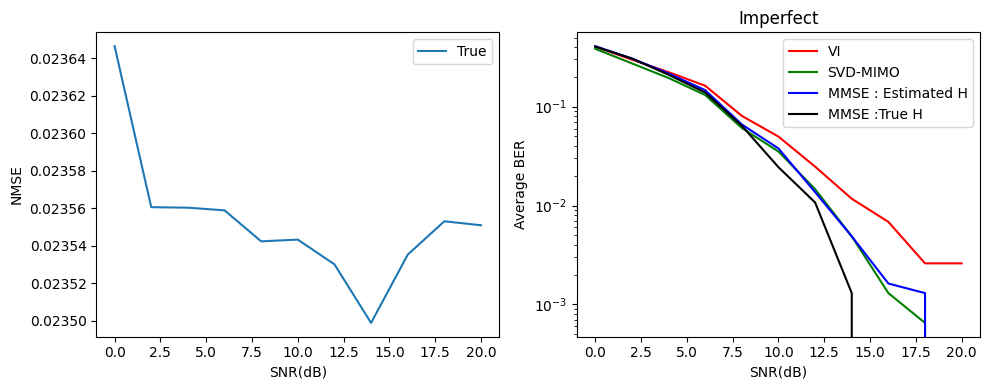

epoch 049 | lr 5.00e-03, recon: 17.65009307861328, kl_x : 9.929201126098633 , kl_H : 1.672698974609375
Execution time: 0.6064507722854614 minutes, epoch: 49


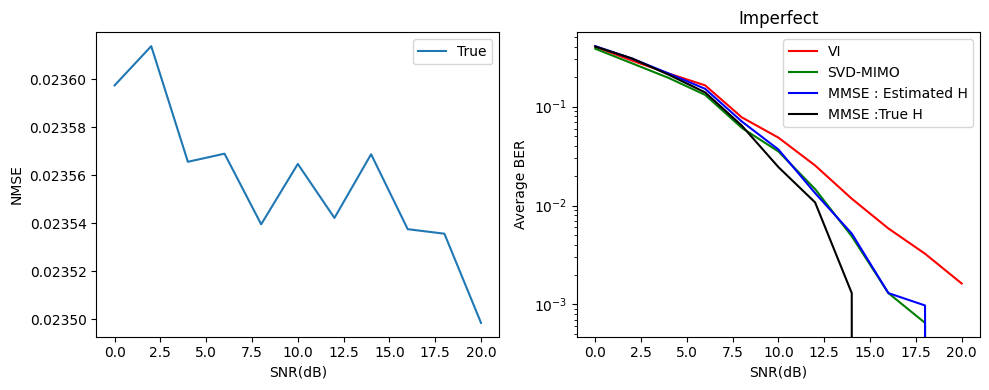

epoch 054 | lr 5.00e-03, recon: 17.991378784179688, kl_x : 10.174072265625 , kl_H : 2.344635009765625
Execution time: 0.6666795969009399 minutes, epoch: 54


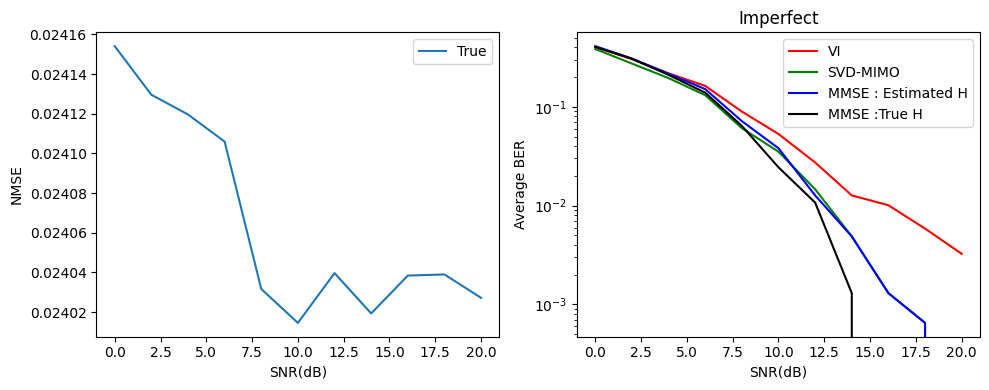

epoch 059 | lr 5.00e-03, recon: 16.977367401123047, kl_x : 10.027565002441406 , kl_H : 1.18804931640625
Execution time: 0.7291892329851787 minutes, epoch: 59


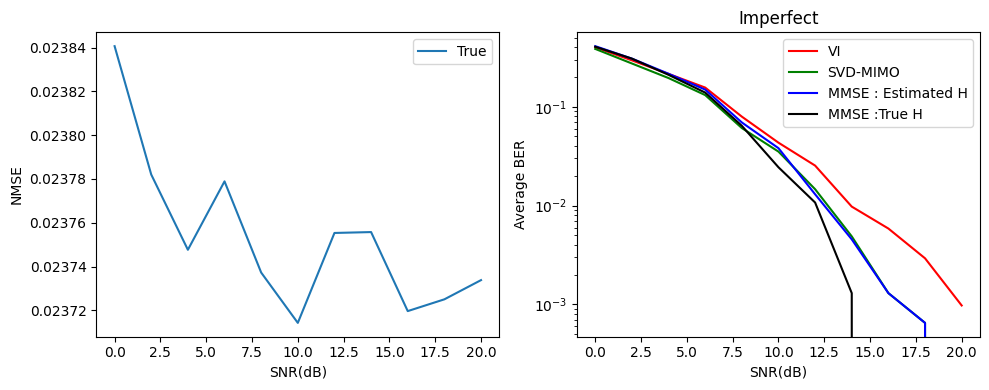

epoch 064 | lr 5.00e-03, recon: 17.504173278808594, kl_x : 10.021398544311523 , kl_H : 1.8568115234375
Execution time: 0.7895826419194539 minutes, epoch: 64


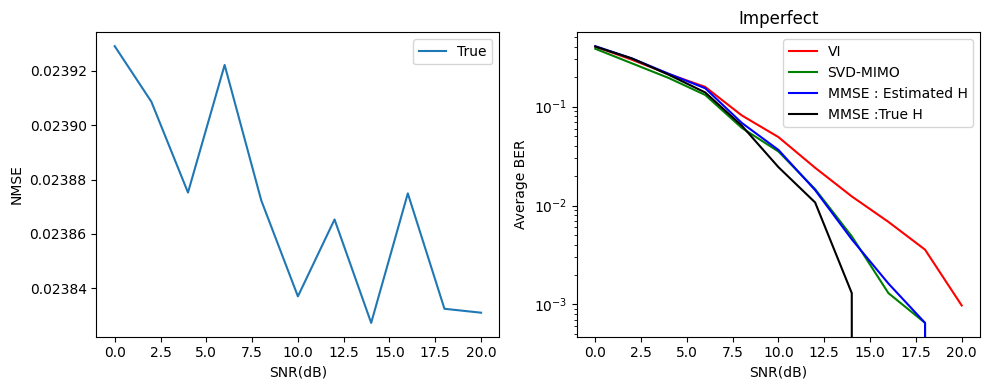

epoch 069 | lr 5.00e-03, recon: 17.40542984008789, kl_x : 9.995817184448242 , kl_H : 1.376678466796875
Execution time: 0.8500270366668701 minutes, epoch: 69


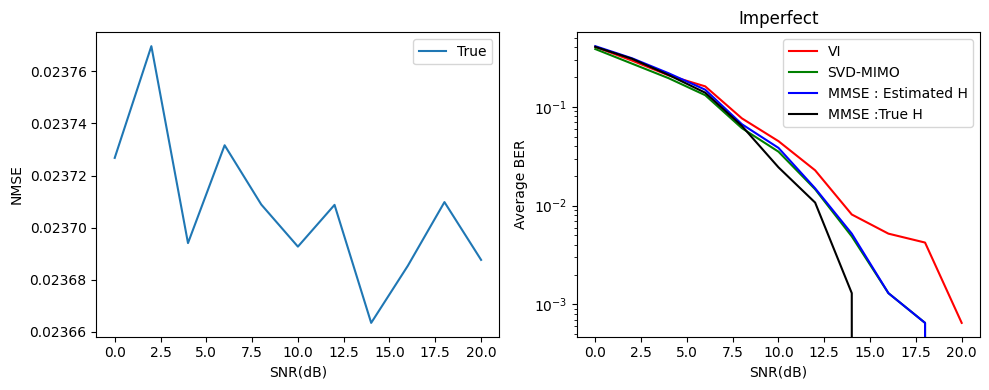

epoch 074 | lr 5.00e-03, recon: 17.230552673339844, kl_x : 10.103704452514648 , kl_H : 1.484619140625
Execution time: 0.9123121500015259 minutes, epoch: 74


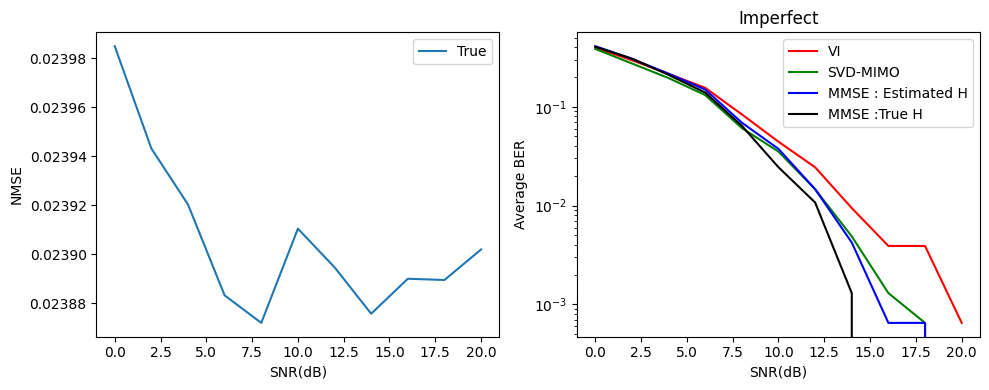

epoch 079 | lr 5.00e-03, recon: 20.450660705566406, kl_x : 9.893857955932617 , kl_H : 5.07843017578125
Execution time: 0.9729880849520366 minutes, epoch: 79


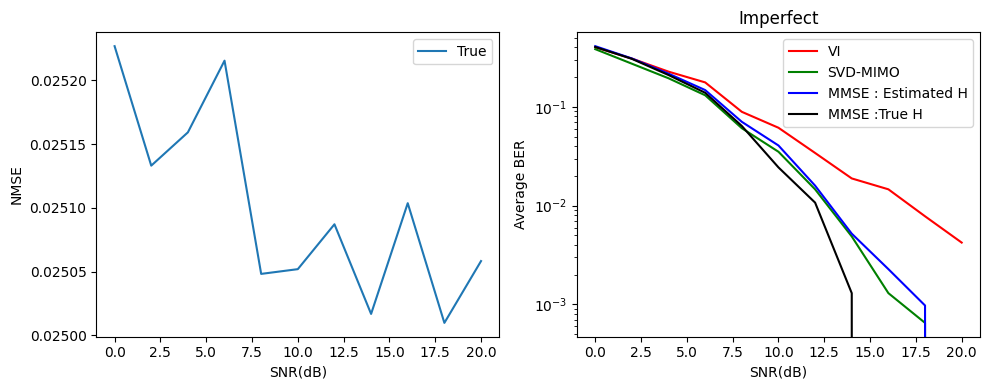

epoch 084 | lr 5.00e-03, recon: 17.043224334716797, kl_x : 9.88204574584961 , kl_H : 1.175933837890625
Execution time: 1.0359779318173727 minutes, epoch: 84


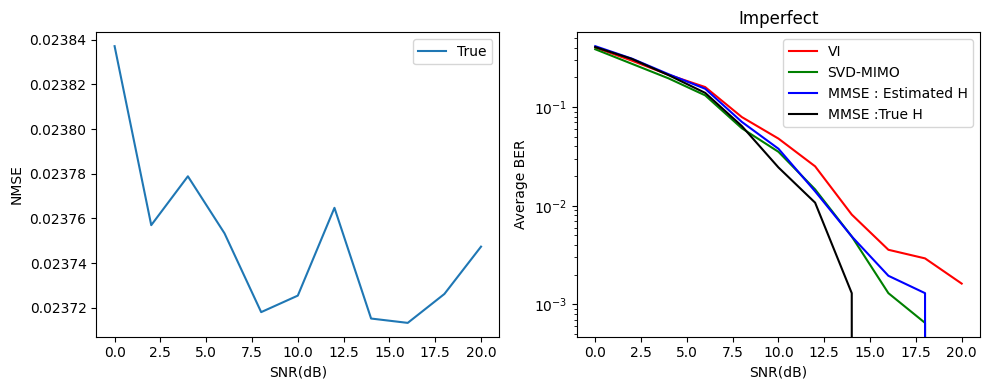

epoch 089 | lr 5.00e-03, recon: 17.75430679321289, kl_x : 9.910165786743164 , kl_H : 1.46405029296875
Execution time: 1.0964510401089986 minutes, epoch: 89


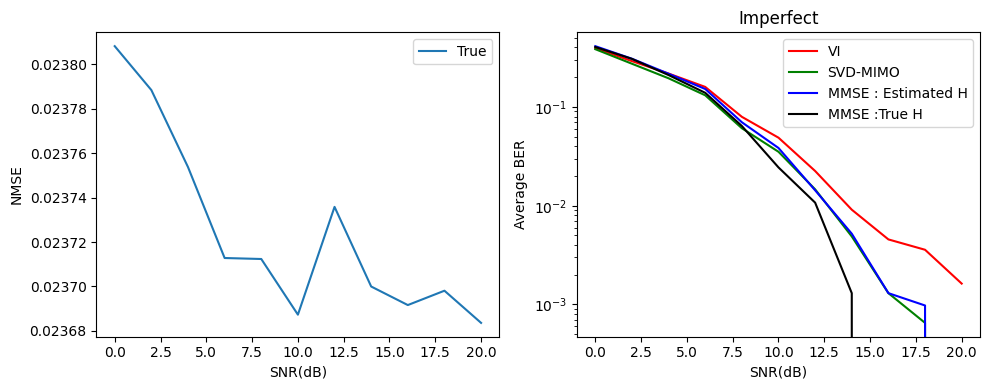

epoch 094 | lr 5.00e-03, recon: 17.4735107421875, kl_x : 9.716716766357422 , kl_H : 1.53033447265625
Execution time: 1.1568759282430012 minutes, epoch: 94


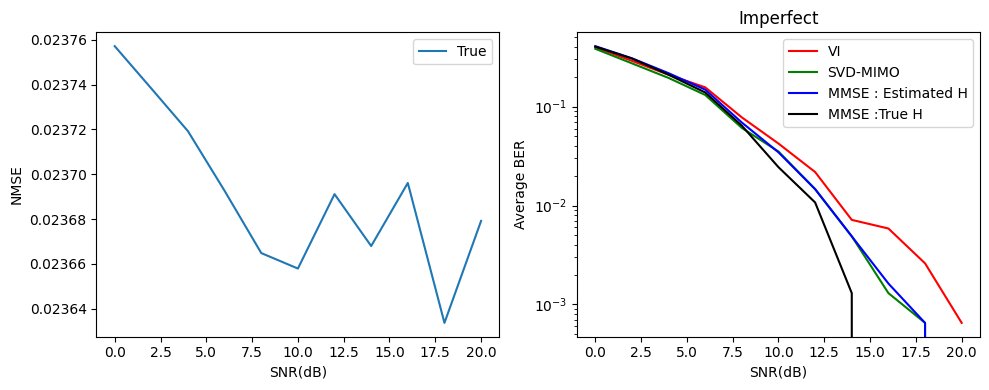

epoch 099 | lr 5.00e-03, recon: 17.777219772338867, kl_x : 9.797948837280273 , kl_H : 1.223541259765625
Execution time: 1.2193453788757325 minutes, epoch: 99


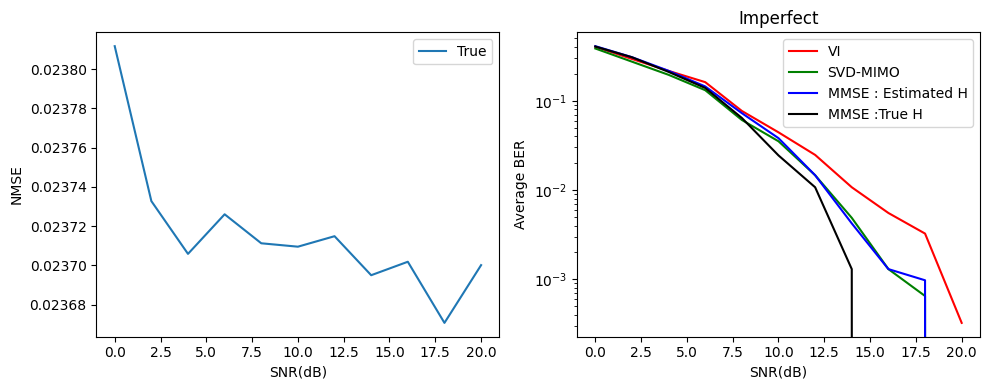

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal, kl_divergence
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split
import random
from itertools import product
import time
import numpy as np
import math
import scipy.io

from scipy.io import savemat

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)

scale = torch.sqrt(torch.tensor(2))
scale_16 = torch.sqrt(torch.tensor(10))
qam16_bit_patterns = torch.tensor([[0,0,0,0], [0,0,0,1], [0,0,1,0], [0,0,1,1],
                                   [0,1,0,0], [0,1,0,1], [0,1,1,0], [0,1,1,1],
                                   [1,0,0,0], [1,0,0,1], [1,0,1,0], [1,0,1,1],
                                   [1,1,0,0], [1,1,0,1], [1,1,1,0], [1,1,1,1]], dtype=torch.long)  
const_pts =  (1/scale_16) * torch.tensor([  -3 + 3j, -3 + 1j, -3 - 3j, -3 - 1j,
                                            -1 + 3j, -1 + 1j, -1 - 3j, -1 - 1j,
                                             3 + 3j,  3 + 1j,  3 - 3j,  3 - 1j,
                                             1 + 3j,  1 + 1j,  1 - 3j,  1 - 1j], dtype=torch.complex64) 
def qam16demod(symbols):
    d2 = torch.abs(symbols.unsqueeze(1) - const_pts.unsqueeze(0))**2  
    idx = torch.argmin(d2, dim=1)  
    bits = qam16_bit_patterns[idx]       
    return bits
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

alpha = 0.99
sigma_h = np.sqrt(1-alpha**2)


snr_levels = 11
SNRdB_range = np.arange(0, 21,2)
test_one_snr_h = 128
train_one_snr = test_one_snr_h*4*4
test_one_snr = test_one_snr_h * 4 
data_size = snr_levels * (train_one_snr+ test_one_snr)
train_size = train_one_snr*snr_levels
test_size = test_one_snr*snr_levels

learning_rates = [5e-3]
weight_decays = [1e-4]
batch_sizes = [1024]
layer_sizes = [1024]
num_layers = [1]

hyperparameter_grid = list(product(weight_decays, learning_rates, batch_sizes, layer_sizes, num_layers))

Nt = 8
Nr = Nt
N = int(Nt*(3/8))


data_file = scipy.io.loadmat(f'mimoData_{Nt}X{Nt}_tv_svd_16qam.mat')

H          = data_file['H']          # numpy.ndarray, dtype=complex128 or float64
Y          = data_file['Y']
X          = data_file['X']
U          = data_file['U']
V          = data_file['V']
H_p        = data_file['H_p']
S          = data_file['S']
Bit_Data   = data_file['Bit_Data']
var_w = data_file['var_w']
Y = torch.from_numpy(Y).cfloat().reshape(data_size, Nr, 1)
X = torch.from_numpy(X).cfloat().reshape(data_size, N, 1)
U = torch.from_numpy(U).cfloat()
V = torch.from_numpy(V).cfloat()
S = torch.diagonal(torch.from_numpy(S).float(), dim1=1, dim2=2) 
H_p = torch.from_numpy(H_p).cfloat()
H = torch.from_numpy(H).cfloat()
Bit_Data = torch.from_numpy(Bit_Data).int()
var_w = torch.from_numpy(var_w).float()

train_dataset = TensorDataset(Y[:train_size,:], H_p[:train_size,:,:], V[:train_size,:,:], var_w[:train_size,:])

I_y = torch.eye(Nr)
log_pi = torch.log(torch.tensor(np.pi))
C_3 = Nr * log_pi 

I_x = torch.eye(N)
sigma_x_2 =  X.reshape(data_size * N).std() ** 2 
sign, log_sigma_x_2 = torch.linalg.slogdet(sigma_x_2 * I_x)
C_1 = -N + log_sigma_x_2

I_h = torch.eye(Nt*Nr)
sigma_h_2 = 2 * sigma_h ** 2 
sign, log_sigma_h_2 = torch.linalg.slogdet(sigma_h_2 * I_h)
C_2 = -((Nr*Nt)) + log_sigma_h_2

class XBranch(nn.Module):
    def __init__(self,  hidden =  1024, n_layers = 1):
        super().__init__()
        layers_x = []
        input_dim = Nr * 2 +  Nt*2   
        for i in range(n_layers):
            layers_x.append(nn.Linear(input_dim, hidden))
            layers_x.append(nn.LeakyReLU(0.2))
            input_dim = hidden
        self.shared_layers_x = nn.Sequential(*layers_x)
        self.x_mean_real = nn.Linear(input_dim, 1)
        self.x_mean_imag = nn.Linear(input_dim, 1)
        self.x_log_var = nn.Linear(input_dim, 1)
        self.activation_sp = nn.Softplus()

    def forward(self, y, eps=1e-8):
        y_x = self.shared_layers_x(y)
        x_mean_real = self.x_mean_real(y_x)
        x_mean_real = x_mean_real.view(-1, 1)
        x_mean_imag =  self.x_mean_imag(y_x)
        x_mean_imag = x_mean_imag.view(-1, 1)
        x_mean = torch.complex(x_mean_real, x_mean_imag) 
        x_log_var = torch.log(self.activation_sp(self.x_log_var(y_x)) + eps)
        return x_mean, x_log_var

class HBranch(nn.Module):
    def __init__(self, hidden = 1024, n_layers = 1):
        super().__init__()        
        layers_H = []
        input_dim = Nr * 2  + Nt *2 * Nr
        for i in range(n_layers):
            layers_H.append(nn.Linear(input_dim, hidden))
            layers_H.append(nn.LeakyReLU(0.2))
            input_dim = hidden
        self.shared_layers_H = nn.Sequential(*layers_H)
        self.H_mean_real = nn.Linear(input_dim, Nr * Nt)
        self.H_mean_imag = nn.Linear(input_dim, Nr * Nt)
        self.H_log_var = nn.Linear(input_dim, Nr * Nt)
        self.activation_sp = nn.Softplus()

    def forward(self, y, eps=1e-8):
        y_H = self.shared_layers_H(y)
        H_mean_real = self.H_mean_real(y_H)
        H_mean_real = H_mean_real.view(-1,  Nr * Nt)
        H_mean_imag = self.H_mean_imag(y_H)
        H_mean_imag = H_mean_imag.view(-1,  Nr * Nt)
        H_mean = torch.complex(H_mean_real, H_mean_imag)   
        H_log_var = torch.log(self.activation_sp(self.H_log_var(y_H)) + eps)
        return H_mean, H_log_var

def reparameterize(mu, log_var, num_samples=1):
    std = torch.exp(0.5 * log_var)
    if num_samples > 1:
        mu = mu.unsqueeze(1).expand(-1, num_samples, -1)
        std = std.unsqueeze(1).expand(-1, num_samples, -1)
        eps = torch.randn_like(std) + 1j * torch.randn_like(std)
        return mu + (1/scale) * std * eps 
    else:
        return mu + std * torch.randn_like(std)

class VI_Encoders(nn.Module):
    def __init__(self, hidden = 1024, n_layers = 1):
        super().__init__()
        self.Nr, self.Nt, self.S = Nr, Nt, N
        self.h_enc = HBranch()#HBranch(hidden, n_layers)
        self.x_encoders = nn.ModuleList(
            [XBranch(hidden, n_layers) for _ in range(self.S)]
        )

    def forward(self, y, V, h_p):
        
        y_H = torch.cat([y.real.reshape(-1, Nr),
                         y.imag.reshape(-1, Nr),
                         h_p.real.reshape(-1, Nt * Nr),
                         h_p.imag.reshape(-1, Nt * Nr)],dim=1)

        H_mean, H_log_var = self.h_enc(y_H)   
        #H_mean_ = reparameterize(H_mean, H_log_var, 1)
        H_mean_mat = H_mean.view(-1, self.Nr, self.Nt) 
        
        x_mu_list, x_logv_list, y_res_list = [], [], []
        y_res = y
        y_res_list.append(y)

        for k, x_enc in enumerate(self.x_encoders):
            Vk = V[:, :, k:k+1]
            hk = torch.matmul(H_mean_mat, Vk.view(-1,Nt,1))
            z = torch.cat([y_res.real.reshape(-1, Nr),
                           y_res.imag.reshape(-1, Nr),                    
                           hk.real.reshape(-1, self.Nt),
                           hk.imag.reshape(-1, self.Nt)],dim=1)

            mu_k, logv_k = x_enc(z)
            x_mu_list.append(mu_k)
            x_logv_list.append(logv_k)

            y_res = y_res - torch.matmul(hk, mu_k.view(-1,1,1))
            y_res_list.append(y_res)

        x_mean = torch.cat(x_mu_list,  dim=1)  
        x_log_var = torch.cat(x_logv_list, dim=1) 
        y_res_all = torch.cat(y_res_list, dim=2)  

        return x_mean, x_log_var , H_mean, H_log_var , y_res_all

def loss1_cal(x_mean, x_log_var, sigma_b, epoch, rho2=1):
    x_mean = x_mean.reshape(-1, N,1)
    trace_term = (1/rho2)*torch.sum(torch.exp(x_log_var), dim=-1)#.mean()   
    mx_term = (1/rho2)*torch.matmul(x_mean.transpose(1, 2).conj(), x_mean)#.mean()   
    logdet_Sx = -torch.sum(x_log_var, dim=-1)#.mean()                    
    loss_total = logdet_Sx + trace_term + mx_term
    loss = loss_total.mean()
    return loss.real + C_1

def loss2_cal(H_mean,H_log_var,h_m, rho2=1):
    H_mean = H_mean.reshape(-1, Nt*Nr,1)
    h_m = h_m.reshape(-1, Nt*Nr,1)
    trace_term = (1/rho2)*torch.sum(torch.exp(H_log_var), dim=-1).view(-1).mean()   
    mh_term = (1/rho2)*(torch.matmul((H_mean- alpha*h_m).transpose(1, 2).conj(),(H_mean-alpha*h_m))).view(-1).mean()
    logdet_SH = -torch.sum(H_log_var, dim=-1).view(-1).mean()                   
    loss = logdet_SH + trace_term + mh_term.real
    return loss + C_2

def loss4_cal(eig, x_mean, x_log_var, H_mean, H_log_var, y, Vb_full, sigma_b, epoch):
    N_eff = N-eig
    Vb = Vb_full[:,:,eig:N].view(y.shape[0], Nt, N_eff)
    
    H_mean_matrix = H_mean.reshape(y.shape[0], Nr, Nt)
    H_log_var_matrix = H_log_var.reshape(y.shape[0], Nr, Nt)
    
    x_mean = x_mean.reshape(y.shape[0], N_eff,1)
    y_hat = torch.matmul(H_mean_matrix , torch.matmul(Vb, x_mean))
    rec_error = torch.norm(y.view(-1,Nr,1)-y_hat, dim=[-2,-1]).pow(2)#.mean()

    Ehth_part1 = torch.matmul(H_mean_matrix.transpose(1, 2).conj(), H_mean_matrix) 
    Ehth_part2 = torch.diag_embed(torch.exp(H_log_var_matrix).sum(dim=1)).cfloat()    
    sx_exp = torch.diag_embed(torch.exp(x_log_var)).cfloat()

    trace1 = torch.matmul(torch.matmul(torch.matmul(torch.matmul(x_mean.transpose(1, 2).conj(), Vb.transpose(1, 2).conj()),Ehth_part2), Vb),x_mean)#.mean()
    trace2 = torch.matmul(torch.matmul(torch.matmul(sx_exp, Vb.transpose(1, 2).conj()),Ehth_part1),Vb).diagonal(dim1=-2, dim2=-1).sum(dim=-1)#.mean()
    trace3 = torch.matmul(torch.matmul(torch.matmul(sx_exp, Vb.transpose(1, 2).conj()),Ehth_part2),Vb).diagonal(dim1=-2, dim2=-1).sum(dim=-1)#.mean()

    sigma_b_n = sigma_b.view(-1)
    trace_term = trace1 + trace2 + trace3 
    sigma_b_inv = (1/sigma_b_n)
    rec_error_sig = torch.mul(sigma_b_inv, rec_error ) 
    trace_term_sig = torch.mul(sigma_b_inv, trace_term )
    loss_total = rec_error_sig + trace_term_sig + Nr * torch.log(sigma_b_n)
    loss = loss_total.mean()
    return loss.real + C_3 

def loss4_cal_mc(eig, x_mean, x_log_var, H_mean, H_log_var, y, Vb_full, sigma_b, epoch):
    mc_samples = 20
    N_eff = N-eig
    y_k = y.reshape(y.shape[0], Nr,1)
    Vb = Vb_full[:,:,eig:N].view(y.shape[0], Nt, N_eff)
    sx_exp = torch.diag_embed(torch.exp(x_log_var)).unsqueeze(1).expand(y.shape[0], mc_samples, N_eff, N_eff).cfloat()
    x_mean = x_mean.reshape(y.shape[0], N_eff,1)
    vx = torch.matmul(Vb, x_mean)
    vx_exp = vx.unsqueeze(1).expand(y.shape[0], mc_samples , Nt, 1)
    
    H_hat = reparameterize(H_mean, H_log_var, mc_samples)
    H_hat_samples = H_hat.reshape(y.shape[0], mc_samples , Nr, Nt) 
    
    y_hat_samples = torch.matmul(H_hat_samples, vx_exp)  
    y_exp = y_k.unsqueeze(1).expand_as(y_hat_samples) 
    rec_error = torch.norm(y_hat_samples-y_exp, dim=[-2,-1]).pow(2).mean(dim=1)  
    
    v_expand = Vb.unsqueeze(1).expand(y.shape[0], mc_samples, Nt, N_eff) 
    Hv = torch.matmul(H_hat_samples, v_expand)
    
    trace_term = torch.matmul(torch.matmul(sx_exp, Hv.transpose(2, 3).conj()), Hv).diagonal(dim1=-2, dim2=-1).sum(dim=-1).mean(dim=1)
    sigma_b_n = sigma_b.view(-1)
    sigma_b_inv = (1/sigma_b_n)
    rec_error_sig = torch.mul(sigma_b_inv, rec_error ) 
    trace_term_sig = torch.mul(sigma_b_inv, trace_term )
    loss_total = rec_error_sig + trace_term_sig + Nr * torch.log(sigma_b_n)
    loss = loss_total.mean()
    return loss.real+ C_3 

def loss_cal(x_mean, x_log_var, H_mean, H_log_var, h_p, y_res, v, sigma_b): 
    loss1 = loss1_cal(x_mean, x_log_var, sigma_b, epoch, sigma_x_2)
    loss2 = loss2_cal(H_mean, H_log_var, h_p, sigma_h_2)
    loss4 = 0
    loss4_arr = []
    for i in range(N):       
        loss = loss4_cal_mc(i, x_mean[:,i:N], x_log_var[:,i:N], H_mean, H_log_var, y_res[:,:,i],  v, sigma_b, epoch)
        loss4 +=loss/N
        loss4_arr.append(loss)
    return loss1 + loss2 + loss4 , loss4_arr,  loss1, loss2, loss4


# Training the model
num_epochs = 200
for wd, lr, batch_size, layer_size, num_layer in hyperparameter_grid:
    print(f"wd {wd}, lr {lr}, batch_size {batch_size}, layer_size {layer_size}, num_layer {num_layer}")
    start_time = time.time()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   
    model = VI_Encoders(layer_size, num_layer).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    
    gamma = (1e-5 / 1e-3) ** (1/20)
    exp_decay = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    constant = torch.optim.lr_scheduler.ConstantLR(
        optimizer,
        factor=1e-2,                    
        total_iters=num_epochs - 20
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[exp_decay, constant],
        milestones=[40]
    )
    
    for epoch in range(num_epochs):
        model.train()
        for y_train, h_p_train, v_train, var_w_train in train_loader:
            y_train = y_train.to(device)
            h_p_train = h_p_train.to(device)
            v_train = v_train.to(device)
            var_w_train = var_w_train.to(device)
            optimizer.zero_grad()
            x_mean, x_log_var, H_mean, H_log_var, y_res= model(y_train, v_train, h_p_train)
            loss  , recon,  kl_x, kl_H , loss4= loss_cal(x_mean, x_log_var, H_mean, H_log_var, h_p_train, y_res, v_train,var_w_train)   
            loss.backward()
            optimizer.step()

        #if(epoch > 20):
        #    scheduler.step()          
        #print(f"epoch {epoch:03d} | lr {optimizer.param_groups[0]['lr']:.2e}, recon: {recon}, kl_x : {kl_x} , kl_H : {kl_H}")
        model.eval() 
        
        if ((epoch+1) % 5) == 0:
            print(f"epoch {epoch:03d} | lr {optimizer.param_groups[0]['lr']:.2e}, recon: {loss4}, kl_x : {kl_x} , kl_H : {kl_H}")
            with torch.no_grad():
                samples  = test_size
                y_test = Y[train_size:train_size+samples, :,:]
                H_test = H[train_size:train_size+samples, :, :] 
                H_P_test = H_p[train_size:train_size+samples, :, :] 
                V_test = V[train_size:train_size+samples, :, 0:N]
                U_test = U[train_size:train_size+samples, :, 0:N]
                Bit_Data_test = qam16_bit_patterns[Bit_Data[train_size:train_size+samples,:]]
                var_w_test = var_w[train_size:train_size+samples]
                S_test = S[train_size:train_size+samples]

                UY = torch.matmul(U_test.conj().transpose(-2,-1), y_test).squeeze(-1)       
                x_hat_svd_test = (UY / S_test[:, :N])[:, :N]  
                
                x_mean, x_log_var, H_mean, H_log_var,_ = model(y_test.to(device), V_test.to(device), H_P_test.to(device))
                H_mean = H_mean.reshape(samples,Nr,Nt) 
                H_test = H_test.reshape(samples,Nr,Nt)        
                               
                sigma2_expand = var_w_test.view(-1, 1, 1).to(device)
                Heff  = torch.matmul(H_mean, V_test.to(device)) 
                Heff_H = Heff.transpose(1, 2).conj()
                HeffH_Heff  = torch.matmul(Heff.transpose(1, 2).conj(), Heff) 
                I = torch.eye(HeffH_Heff.size(-1),  device=H_mean.device).expand_as(HeffH_Heff)
                inverse_term = torch.linalg.inv(HeffH_Heff + sigma2_expand/sigma_x_2 * I )
                Hy = torch.matmul(Heff_H, y_test.to(device))  # [B, N, 1]
                x_hat_mmse = torch.matmul(inverse_term, Hy)

                Heff  = torch.matmul(H_test.to(device), V_test.to(device)) 
                Heff_H = Heff.transpose(1, 2).conj()
                HeffH_Heff  = torch.matmul(Heff.transpose(1, 2).conj(), Heff) 
                I = torch.eye(HeffH_Heff.size(-1),  device=H_mean.device).expand_as(HeffH_Heff)
                inverse_term = torch.linalg.inv(HeffH_Heff + sigma2_expand/sigma_x_2 * I)
                Hy = torch.matmul(Heff_H, y_test.to(device))  # [B, N, 1]             
                x_hat_mmse_true = torch.matmul(inverse_term, Hy)

                N_ = N
                ber_array_ours_i = torch.zeros(N_,snr_levels)
                ber_array_svd_i = torch.zeros(N_,snr_levels)
                ber_array_mmse_i = torch.zeros(N_,snr_levels)
                ber_array_mmse_true_i = torch.zeros(N_,snr_levels)
                
                for i in range(snr_levels):
                    l = i*test_one_snr 
                    h = (i+1)*test_one_snr 
                    for j in range(N_):
                        bit_snr = Bit_Data_test[l:h,j,:]
                        
                        symbol_flatten = x_mean[l:h,j].cpu().reshape(test_one_snr)
                        detected_bits = qam16demod(symbol_flatten) 
                        error_mask = (bit_snr != detected_bits)     
                        ber = (error_mask.float().sum())/(test_one_snr*2)
                        ber_array_ours_i[j,i] = ber

                        symbol_flatten = x_hat_svd_test[l:h,j].reshape(test_one_snr)
                        detected_bits = qam16demod(symbol_flatten) 
                        error_mask = (bit_snr != detected_bits)     
                        ber = (error_mask.float().sum())/(test_one_snr*2)
                        ber_array_svd_i[j,i] = ber

                        
                        symbol_flatten = x_hat_mmse[l:h,j].cpu().reshape(test_one_snr)
                        detected_bits = qam16demod(symbol_flatten) 
                        error_mask = (bit_snr != detected_bits)     
                        ber = (error_mask.float().sum())/(test_one_snr*2)
                        ber_array_mmse_i[j,i] = ber

                        symbol_flatten = x_hat_mmse_true[l:h,j].cpu().reshape(test_one_snr)
                        detected_bits = qam16demod(symbol_flatten) 
                        error_mask = (bit_snr != detected_bits)     
                        ber = (error_mask.float().sum())/(test_one_snr*2)
                        ber_array_mmse_true_i[j,i] = ber

                #print(ber_array_ours_i)
                #print(ber_array_svd_i)
                
                end_time = time.time()
                elapsed_time = end_time - start_time            
                
                print(f'Execution time: {elapsed_time/60} minutes, epoch: {epoch}')                     

                mse_array_i = []
                mse_array_p = []
                for i in range(snr_levels):
                    l = i*test_one_snr 
                    h = (i+1)*test_one_snr 
                    mse = torch.mean(torch.pow(torch.norm(H_test[l:h,:,:]-H_mean[l:h,:,:].cpu(), dim=[-2,-1]),2))/ torch.mean(torch.pow(torch.norm(H_test[l:h,:,:], dim=[-2,-1]),2))
                    mse_array_i.append(mse)
                    mse = torch.mean(torch.pow(torch.norm(H_P_test[l:h,:,:]-H_mean[l:h,:,:].cpu(), dim=[-2,-1]),2))/ torch.mean(torch.pow(torch.norm(H_P_test[l:h,:,:], dim=[-2,-1]),2))
                    mse_array_p.append(mse)

                plt.figure(figsize=(10, 4))
                plt.subplot(1 ,2, 1)
                plt.plot(SNRdB_range, mse_array_i, label='True')
                #plt.plot(SNRdB_range, mse_array_p, label='Prior')
                plt.xlabel('SNR(dB)')
                plt.ylabel('NMSE')
                plt.legend()

                '''
                plt.subplot(1 ,3, 2)
                plt.semilogy(SNRdB_range, ber_array_ours_i[0,:], color='r', label='Eig1')
                plt.semilogy(SNRdB_range, ber_array_ours_i[1,:], color='g', label='Eig2')
                plt.semilogy(SNRdB_range, ber_array_ours_i[3,:], color='m', label='Eig4')
                plt.semilogy(SNRdB_range, ber_array_ours_i[4,:], color='b', label='Eig5')
                plt.semilogy(SNRdB_range, ber_array_ours_i[5,:], color='k', label='Eig6') 
                plt.semilogy(SNRdB_range, ber_array_svd_i[0,:], color='r', linestyle='--')
                plt.semilogy(SNRdB_range, ber_array_svd_i[1,:], color='g', linestyle='--')
                plt.semilogy(SNRdB_range, ber_array_svd_i[3,:], color='m', linestyle='--')
                plt.semilogy(SNRdB_range, ber_array_svd_i[4,:], color='b', linestyle='--')
                plt.semilogy(SNRdB_range, ber_array_svd_i[5,:], color='k', linestyle='--')
                plt.semilogy(SNRdB_range, ber_array_mmse_i[0,:], color='r', linestyle='-.')
                plt.semilogy(SNRdB_range, ber_array_mmse_i[1,:], color='g', linestyle='-.')
                plt.semilogy(SNRdB_range, ber_array_mmse_i[3,:], color='m', linestyle='-.')
                plt.semilogy(SNRdB_range, ber_array_mmse_i[4,:], color='b', linestyle='-.')
                plt.semilogy(SNRdB_range, ber_array_mmse_i[5,:], color='k', linestyle='-.')  
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i[0,:], color='r', linestyle='dotted')
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i[1,:], color='g', linestyle='dotted')
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i[3,:], color='m', linestyle='dotted')
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i[4,:], color='b', linestyle='dotted')
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i[5,:], color='k', linestyle='dotted')  
                plt.xlabel('SNR(dB)')
                plt.ylabel('BER')
                plt.title('Imperfect')
                plt.legend()
                '''

                plt.subplot(1 ,2, 2)
                plt.semilogy(SNRdB_range, ber_array_ours_i.mean(dim=0), color='r', label='VI')      
                plt.semilogy(SNRdB_range, ber_array_svd_i.mean(dim=0), color='g', label='SVD-MIMO')
                plt.semilogy(SNRdB_range, ber_array_mmse_i.mean(dim=0), color='b', label='MMSE : Estimated H')
                plt.semilogy(SNRdB_range, ber_array_mmse_true_i.mean(dim=0), color='k', label='MMSE :True H')
                plt.xlabel('SNR(dB)')
                plt.ylabel('Average BER')
                plt.title('Imperfect')
                plt.legend()
                plt.tight_layout()
                plt.show()

            #if(ber_array_ours_i.mean(dim=0)[-1] <  0.6 * ber_array_svd_i.mean(dim=0)[-1]):
            if(epoch+1 == 100):
                #print(ber_array_ours_i.mean(dim=0))
                #print(ber_array_svd_i.mean(dim=0))
                #break;
                    savemat('results_alpha_0_99_16qam.mat', {
                        'x_mean': x_mean.cpu()
                    })

                    break;
                
